In [4]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt

# Load your combined Visium data
adata = sc.read_h5ad("./spatial_bladder_4/GSE171351_combined_visium.h5ad")    

# Inspect the object
print(adata)
print(adata.obs.head())
print(adata.obsm.keys())




AnnData object with n_obs × n_vars = 4086 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'sampleID', 'Patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial'
                          in_tissue  array_row  array_col sampleID  \
AAACCGTTCGTCCAGG-1-0-0-0          1         52         42       A1   
AAACGAGACGGTTGAT-1-0-0-0          1         35         79       A1   
AAACTGCTGGCTCCAA-1-0-0-0          1         45         67       A1   
AAAGGCTACGGACCAT-1-0-0-0          1         62         54       A1   
AAAGGCTCTCGCGCCG-1-0-0-0          1 

In [5]:
import os
print(os.getcwd())


from PIL import Image
from skimage.io import imread
import os

#Image.MAX_IMAGE_PIXELS = None  # disable decompression bomb check

#from skimage.transform import resize

#img = imread(img_path)
##img = resize(img, (5000, 5000), anti_aliasing=True)  # shrink to 5000x5000 pixels



/Users/ebouvet/Desktop/Spatial_experimenting


In [6]:
import os
from skimage.io import imread
Image.MAX_IMAGE_PIXELS = None  # disable decompression bomb check
# Define the folder where your images are located (relative to current working directory)
img_folder = "./spatial_bladder_4"  # current folder

#Map library IDs to image filenames
image_files = {
    "A1": "GSM5224027_A1.jpg",
    "B1": "GSM5224028_B1.jpg",
    "C1": "GSM5224029_C1.jpg",
    "D1": "GSM5224030_D1.jpg"
}

# Attach images to the AnnData object
for lib_id, filename in image_files.items():
    img_path = os.path.join(img_folder, filename)  # build relative path
    if not os.path.exists(img_path):
        print(f"Warning: {img_path} not found!")
        continue
    
    img = imread(img_path)
    
    if 'spatial' not in adata.uns:
        adata.uns['spatial'] = {}
    
    if lib_id not in adata.uns['spatial']:
        adata.uns['spatial'][lib_id] = {}
    
    adata.uns['spatial'][lib_id]['images'] = {'hires': img}#

 #Save the updated AnnData object
adata.write_h5ad("GSE171351_combined_visium_with_images.h5ad")
print("Images successfully attached and AnnData saved.")




Images successfully attached and AnnData saved.


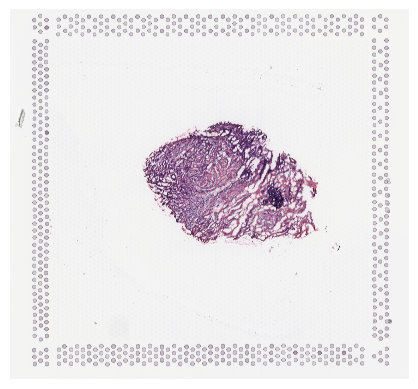

In [7]:
import matplotlib.pyplot as plt

plt.imshow(adata.uns['spatial']['A1']['images']['hires'])
plt.axis('off')
plt.show()




In [13]:
for lib_id in adata.uns['spatial'].keys():
    subset = adata[adata.obs['sampleID'] == lib_id]
    coords = subset.obsm['spatial']
    img = adata.uns['spatial'][lib_id]['images']['hires']
    
    print(f"\nLibrary {lib_id}:")
    print(f"  Image shape: {img.shape[:2]} (height, width)")
    print(f"  X range: {coords[:,0].min():.1f} - {coords[:,0].max():.1f}")
    print(f"  Y range: {coords[:,1].min():.1f} - {coords[:,1].max():.1f}")

    
for lib_id in adata.uns['spatial'].keys():
    subset_mask = adata.obs['sampleID'] == lib_id
    coords = adata.obsm['spatial'][subset_mask].copy()
    img = adata.uns['spatial'][lib_id]['images']['hires']
    h, w = img.shape[:2]

    # Shift coordinates so the smallest x,y start at (0,0)
    coords[:, 0] = coords[:, 0] - coords[:, 0].min()
    coords[:, 1] = coords[:, 1] - coords[:, 1].min()

    # Flip y-axis if it appears upside down (Visium images usually have origin at top-left)
    coords[:, 1] = h - coords[:, 1]

    # Write back
    adata.obsm['spatial'][subset_mask] = coords

print("Coordinate offsets adjusted per library.")




Library A1:
  Image shape: (16208, 17496) (height, width)
  X range: 0.0 - 7485.0
  Y range: 10985.0 - 16208.0

Library B1:
  Image shape: (16208, 17496) (height, width)
  X range: 0.0 - 10155.0
  Y range: 10777.0 - 16208.0

Library C1:
  Image shape: (16208, 17496) (height, width)
  X range: 0.0 - 8375.0
  Y range: 6276.0 - 16208.0

Library D1:
  Image shape: (16208, 17170) (height, width)
  X range: 0.0 - 8191.0
  Y range: 8523.0 - 16208.0
Coordinate offsets adjusted per library.


Plotting A1...
Plotting B1...
Plotting C1...
Plotting D1...


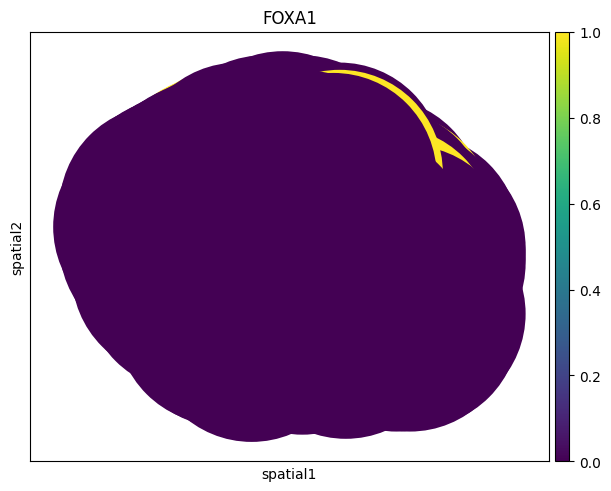

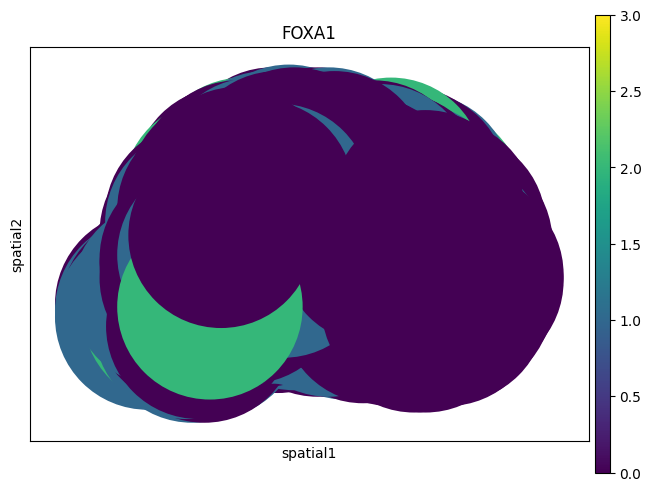

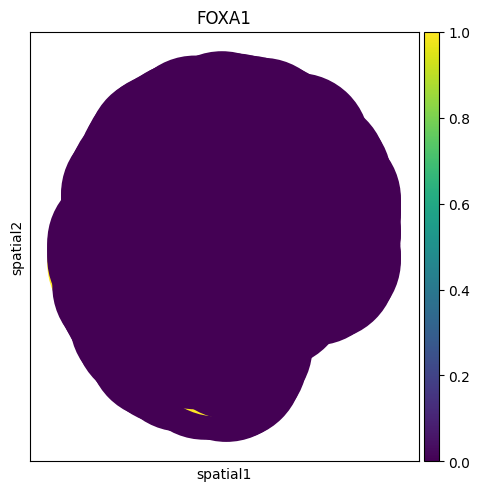

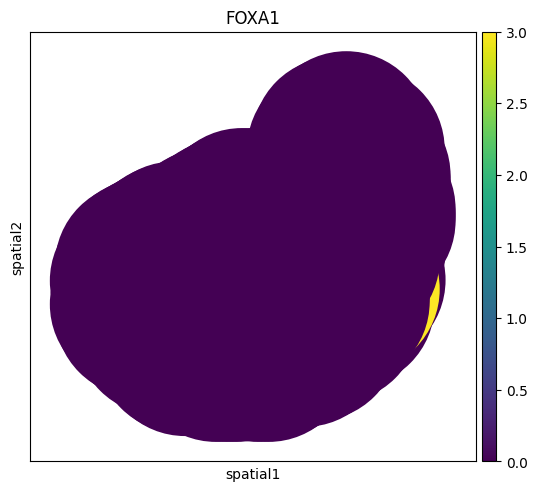

In [34]:
import squidpy as sq
import matplotlib.pyplot as plt

genes = ["FOXA1"]

for lib_id in adata.uns['spatial'].keys():
    print(f"Plotting {lib_id}...")
    
    sq.pl.spatial_scatter(
        adata[adata.obs['sampleID'] == lib_id],  # <- use sampleID here
        color=genes,
        library_id=lib_id,
        spatial_key="spatial",
        img=False,
        size=1.5
        #ncols=2  # FOXA1 and FOXA2 side by side
    )



In [ ]:
import numpy as np
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, binary_closing, disk

def auto_align_spots_to_image(adata, image_key='hires', sample_key='sampleID', min_tissue_area=1000):
    """
    Auto-align spot coordinates to the tissue image by matching centroids.
    - adata: AnnData with adata.uns['spatial'][lib]['images'][image_key] present
    - image_key: key under images dict ('hires' in your case)
    - sample_key: column name in adata.obs identifying the library (your 'sampleID')
    Returns a dict of applied shifts per library: {lib_id: (dx, dy)}
    """
    shifts = {}
    for lib_id in adata.uns['spatial'].keys():
        # mask for spots of this library
        mask = adata.obs[sample_key] == lib_id
        if mask.sum() == 0:
            print(f"Warning: no spots found for {lib_id}, skipping.")
            continue

        img = adata.uns['spatial'][lib_id]['images'][image_key]
        if img is None:
            print(f"Warning: no image for {lib_id}, skipping.")
            continue

        h, w = img.shape[:2]

        # --- compute image tissue centroid ---
        # convert to grayscale intensity and robustly threshold
        if img.ndim == 3 and img.shape[2] >= 3:
            gray = rgb2gray(img[..., :3])
        else:
            gray = img if img.ndim == 2 else np.mean(img, axis=2)

        # Otsu threshold (robust) + simple morphological cleanup
        try:
            thresh = threshold_otsu(gray)
            tissue_mask = gray < thresh  # tissue is darker in H&E-ish images
        except Exception:
            # fallback to a small constant threshold if Otsu fails
            tissue_mask = gray < (np.mean(gray) * 0.95)

        # clean up mask
        tissue_mask = binary_closing(tissue_mask, footprint=disk(5))
        tissue_mask = remove_small_objects(tissue_mask, min_size=min_tissue_area)

        # if mask is empty try inverted thresholding
        if tissue_mask.sum() == 0:
            tissue_mask = gray > (np.mean(gray) * 1.01)
            tissue_mask = remove_small_objects(tissue_mask, min_size=min_tissue_area)

        if tissue_mask.sum() == 0:
            print(f"Warning: unable to detect tissue mask for {lib_id}. Skipping automatic alignment.")
            continue

        # image centroid (y_img, x_img) in pixel coords
        ys, xs = np.nonzero(tissue_mask)
        img_cy = ys.mean()
        img_cx = xs.mean()

        # --- compute spot centroid in same pixel coordinate system ---
        coords = adata.obsm['spatial'][mask].copy()  # Nx2 (x,y) as in your object
        # Step A: shift coords so min is at 0 (we assume coords are already in pixel space but not zero-based)
        coords[:, 0] = coords[:, 0] - coords[:, 0].min()
        coords[:, 1] = coords[:, 1] - coords[:, 1].min()

        # Step B: flip y to image coordinate system (image origin is top-left)
        # We must use same convention as for plotting: y_img = h - y_spot
        coords[:, 1] = h - coords[:, 1]

        # spot centroid (y_spot, x_spot) in pixel coords
        spot_cx = coords[:, 0].mean()
        spot_cy = coords[:, 1].mean()

        # --- compute required translation (dx, dy) to move spot centroid -> image centroid ---
        # dx = how much to add to spot x to match image cx
        dx = img_cx - spot_cx
        dy = img_cy - spot_cy

        # Apply translation to coords (we will rewrite into adata.obsm)
        coords = coords.astype(float)
        aligned = coords.copy()
        aligned[:, 0] += dx
        aligned[:, 1] += dy

        # Write aligned coordinates back into adata.obsm for those spots
        # Note: we must place them back in the correct rows
        row_idx = np.where(mask)[0]
        adata.obsm['spatial'][row_idx, 0] = aligned[:, 0]
        adata.obsm['spatial'][row_idx, 1] = aligned[:, 1]

        shifts[lib_id] = (dx, dy)
        print(f"{lib_id}: img_centroid=({img_cx:.1f},{img_cy:.1f}), spot_centroid=({spot_cx:.1f},{spot_cy:.1f}), applied shift dx={dx:.1f}, dy={dy:.1f}")

    return shifts

# run it
shifts = auto_align_spots_to_image(adata)
print("Done. shifts:", shifts)




A1: img_centroid=(9229.3,7861.1), spot_centroid=(3796.9,13705.3), applied shift dx=5432.4, dy=-5844.2
B1: img_centroid=(9071.9,8330.9), spot_centroid=(5382.4,13556.0), applied shift dx=3689.5, dy=-5225.1
C1: img_centroid=(10390.2,7694.0), spot_centroid=(4048.9,10901.2), applied shift dx=6341.3, dy=-3207.1
D1: img_centroid=(8523.8,8534.4), spot_centroid=(4170.3,13501.3), applied shift dx=4353.5, dy=-4966.9
Done. shifts: {'A1': (np.float64(5432.439771395599), np.float64(-5844.219316018662)), 'B1': (np.float64(3689.51622128291), np.float64(-5225.108343585938)), 'C1': (np.float64(6341.305335671672), np.float64(-3207.13045965924)), 'D1': (np.float64(4353.49529183468), np.float64(-4966.895234206935))}


In [29]:
for lib_id, (dx, dy) in shifts.items():
    scale = adata.uns["spatial"][lib_id]["scalefactors"]["tissue_lowres_scalef"]
    coords = adata.obsm["spatial"][adata.obs["sampleID"] == lib_id].astype(float)

    # Apply the shift in image coordinate space
    coords[:, 0] += dx
    coords[:, 1] += dy

    # Rescale to lowres space
    coords[:, 0] = coords[:, 0] * scale
    coords[:, 1] = coords[:, 1] * scale

    adata.obsm["spatial"][adata.obs["sampleID"] == lib_id] = coords


In [ ]:
adata.obs["library_id"] = [
    name.split("_")[0] for name in adata.obs_names
]
adata.obs.columns
adata.uns["spatial"].keys()



print(adata)



AnnData object with n_obs × n_vars = 4086 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'sampleID', 'Patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'library_id'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial'


Plotting A1...
Plotting B1...
Plotting C1...
Plotting D1...


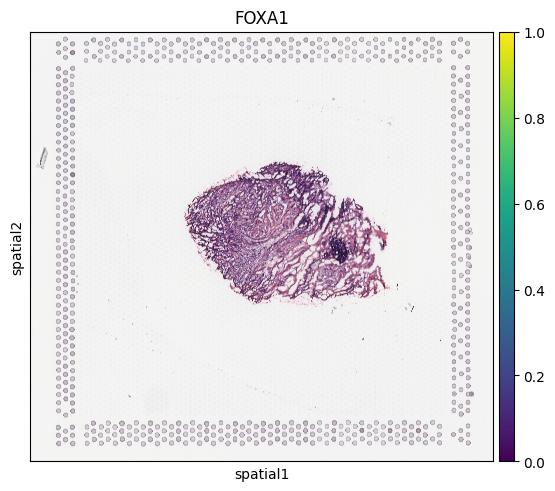

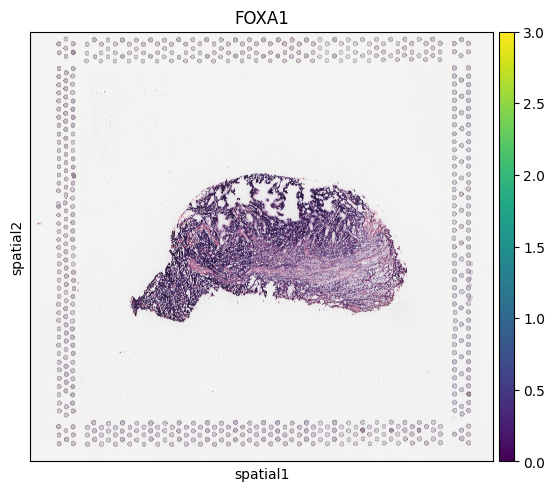

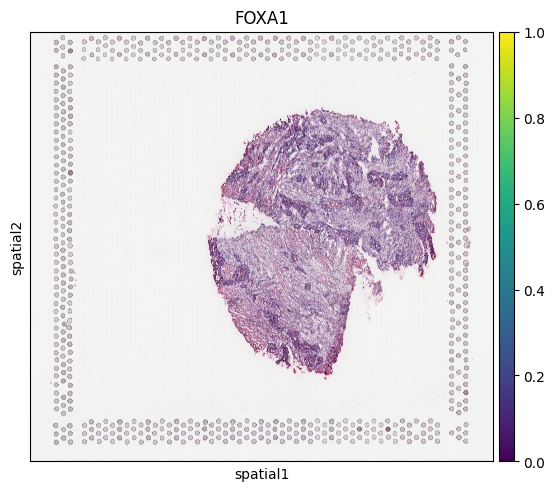

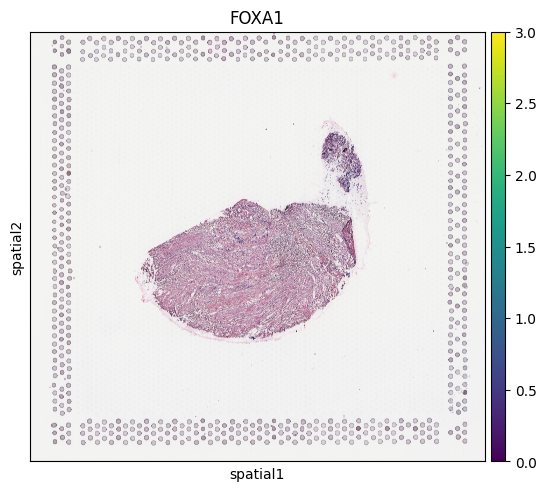

In [36]:
import squidpy as sq
import matplotlib.pyplot as plt

genes = ["FOXA1"]

for lib_id in adata.uns['spatial'].keys():
    print(f"Plotting {lib_id}...")
    
    sq.pl.spatial_scatter(
        adata[adata.obs['sampleID'] == lib_id],  # <- use sampleID here
        color=genes,
        library_id=lib_id,
        spatial_key="spatial",
        img=True
        #size=1.5,
        #ncols=2  # FOXA1 and FOXA2 side by side
    )

In [31]:
lib_id = "A1"
img = adata.uns["spatial"][lib_id]["images"]["hires"]
coords = adata.obsm["spatial"][adata.obs["library_id"] == lib_id]

print(f"Image shape: {img.shape} (height, width)")
print(f"Coord range X: {coords[:,0].min():.1f} - {coords[:,0].max():.1f}")
print(f"Coord range Y: {coords[:,1].min():.1f} - {coords[:,1].max():.1f}")


Image shape: (16208, 17496, 3) (height, width)


ValueError: zero-size array to reduction operation minimum which has no identity